# 🛡️ KIỂM THỬ MÔ HÌNH LSTM PHÁT HIỆN TẤN CÔNG DDOS
### Đánh giá trên tập dữ liệu Test độc lập (CIC-DDoS2019 - 03/11)
---
**Notebook này thực hiện:**
- Load mô hình `ddos_multiclass_final.keras` đã huấn luyện
- Nạp và tiền xử lý tập test độc lập (`csv-03-11/testing/scaled/`)
- Dự đoán và đánh giá toàn diện: Accuracy, F1, Confusion Matrix, ROC
- So sánh hiệu năng Train vs Test
- Xuất kết quả chi tiết ra file CSV

## ⚙️ PHẦN 1: THIẾT LẬP MÔI TRƯỜNG & NẠP MÔ HÌNH

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Tắt cảnh báo để giao diện sạch sẽ
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import keras

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

# ============================================================
# CẤU HÌNH ĐƯỜNG DẪN  <-- Chỉnh sửa 2 dòng này nếu cần
# ============================================================
MODEL_PATH       = r"D:\detection_ddos\notebooks\ddos_multiclass_final.keras"
TEST_FOLDER_PATH = r"D:\detection_ddos\data\CSV-03-11\testing\scaled\scaled (1)\scaled"
OUTPUT_REPORT    = r"D:\detection_ddos\src\test_results_report.csv"
SAMPLES_PER_FILE = 20000  # Giữ nguyên như khi training để cân bằng

# ============================================================
# DANH SÁCH LỚP - Phải khớp CHÍNH XÁC với thứ tự khi training
# (LabelEncoder.fit() sắp xếp theo alphabet)
# ============================================================
CLASS_NAMES = [
    'LSTM_DrDos_DNS_scaled',
    'LSTM_DrDos_LDAP_scaled',
    'LSTM_DrDos_MSSQL_scaled',
    'LSTM_DrDos_NTP_scaled',
    'LSTM_DrDos_NetBIOS_scaled',
    'LSTM_DrDos_SNMP_scaled',
    'LSTM_DrDos_SSDP_scaled',
    'LSTM_DrDos_UDP_scaled',
    'LSTM_Syn_scaled',
    'LSTM_TFTP_scaled',
    'LSTM_UDPLag_scaled',
    'Normal'
]

# Tên hiển thị ngắn gọn (dùng cho biểu đồ)
CLASS_DISPLAY = [
    'DrDoS DNS', 'DrDoS LDAP', 'DrDoS MSSQL', 'DrDoS NTP', 'DrDoS NetBIOS',
    'DrDoS SNMP', 'DrDoS SSDP', 'DrDoS UDP', 'SYN Flood', 'TFTP', 'UDPLag', 'Normal'
]

# Tái tạo LabelEncoder với đúng thứ tự classes như khi training
encoder = LabelEncoder()
encoder.classes_ = np.array(CLASS_NAMES)
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n✅ Số lớp phân loại : {NUM_CLASSES}")
print(f"✅ Các lớp          : {CLASS_NAMES}")

# ============================================================
# NẠP MÔ HÌNH ĐÃ HUẤN LUYỆN
# ============================================================
print(f"\n📦 Đang nạp mô hình từ: {MODEL_PATH}")
model = keras.models.load_model(MODEL_PATH)
model.summary()
print("\n✅ Nạp mô hình thành công!")

TensorFlow version : 2.21.0
Keras version      : 3.14.0

✅ Số lớp phân loại : 12
✅ Các lớp          : ['LSTM_DrDos_DNS_scaled', 'LSTM_DrDos_LDAP_scaled', 'LSTM_DrDos_MSSQL_scaled', 'LSTM_DrDos_NTP_scaled', 'LSTM_DrDos_NetBIOS_scaled', 'LSTM_DrDos_SNMP_scaled', 'LSTM_DrDos_SSDP_scaled', 'LSTM_DrDos_UDP_scaled', 'LSTM_Syn_scaled', 'LSTM_TFTP_scaled', 'LSTM_UDPLag_scaled', 'Normal']

📦 Đang nạp mô hình từ: D:\detection_ddos\notebooks\ddos_multiclass_final.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │          78,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             396 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 392,198 (1.50 MB)

 Trainable params: 130,732 (510.67 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 261,466 (1021.36 KB)


✅ Nạp mô hình thành công!


## 📂 PHẦN 2: NẠP & CHUẨN BỊ DỮ LIỆU TEST ĐỘC LẬP

In [2]:
# ============================================================
# NẠP DỮ LIỆU TEST - Dùng CÙNG logic khôi phục nhãn như training
# ============================================================
all_test_files = glob.glob(os.path.join(TEST_FOLDER_PATH, "*.csv"))

if not all_test_files:
    raise FileNotFoundError(
        f"❌ Không tìm thấy file CSV nào trong: {TEST_FOLDER_PATH}\n"
        f"   Hãy kiểm tra lại đường dẫn TEST_FOLDER_PATH ở Phần 1."
    )

print(f"📁 Tìm thấy {len(all_test_files)} file test:")
print("-" * 60)

df_test_list = []
file_summary = []

for file in sorted(all_test_files):
    attack_name = os.path.basename(file).replace('.csv', '')
    
    temp_df = pd.read_csv(file)
    temp_df.columns = temp_df.columns.str.strip()
    total_rows = len(temp_df)
    
    if 'Label' not in temp_df.columns:
        print(f"  ⚠️  {attack_name}: Bỏ qua - Không có cột 'Label'")
        continue
    
    # Khôi phục nhãn text - GIỐNG HỆT logic trong lstm_training.ipynb
    temp_df['Label'] = temp_df['Label'].apply(
        lambda x: 'Normal' if str(x).strip() in ['0', '0.0', 'BENIGN', 'Normal'] else attack_name
    )
    
    # Sampling để cân bằng (giữ nguyên như training)
    n_samples = min(SAMPLES_PER_FILE, total_rows)
    if total_rows > SAMPLES_PER_FILE:
        temp_df = temp_df.sample(n=n_samples, random_state=42)
    
    label_dist = temp_df['Label'].value_counts().to_dict()
    file_summary.append({
        'File': attack_name,
        'Tổng dòng gốc': total_rows,
        'Dòng được dùng': n_samples,
        'Label chính': max(label_dist, key=label_dist.get)
    })
    print(f"  ✅ {attack_name:<35} | {n_samples:>6,} / {total_rows:>8,} dòng")
    df_test_list.append(temp_df)

# Gộp tất cả file
df_test = pd.concat(df_test_list, ignore_index=True)

print("-" * 60)
print(f"\n📊 TỔNG KẾT TẬP TEST:")
print(f"   Tổng số dòng  : {len(df_test):,}")
print(f"   Tổng số file  : {len(df_test_list)}")
print(f"\n   Phân phối nhãn:")
label_counts = df_test['Label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_test) * 100
    print(f"   {label:<35} : {count:>6,} dòng ({pct:.1f}%)")

📁 Tìm thấy 7 file test:
------------------------------------------------------------
  ✅ LSTM_LDAP_scaled                    | 13,849 /   13,849 dòng
  ✅ LSTM_MSSQL_scaled                   |  7,982 /    7,982 dòng
  ✅ LSTM_NetBIOS_scaled                 |  3,775 /    3,775 dòng
  ✅ LSTM_Portmap_scaled                 | 13,525 /   13,525 dòng
  ✅ LSTM_Syn_scaled                     | 20,000 /  119,300 dòng
  ✅ LSTM_UDPLag_scaled                  | 10,170 /   10,170 dòng
  ✅ LSTM_UDP_scaled                     |  7,835 /    7,835 dòng
------------------------------------------------------------

📊 TỔNG KẾT TẬP TEST:
   Tổng số dòng  : 77,136
   Tổng số file  : 7

   Phân phối nhãn:
   Normal                              : 27,123 dòng (35.2%)
   LSTM_Syn_scaled                     : 14,052 dòng (18.2%)
   LSTM_Portmap_scaled                 :  8,791 dòng (11.4%)
   LSTM_LDAP_scaled                    :  8,725 dòng (11.3%)
   LSTM_UDPLag_scaled                  :  6,102 dòng (7.9%)
   LST

## 🔄 PHẦN 3: TIỀN XỬ LÝ & DỰ ĐOÁN

In [3]:
# ============================================================
# BƯỚC 3.1: MÃ HÓA NHÃN
# ============================================================
# Kiểm tra nhãn không nằm trong danh sách training
unknown_labels = set(df_test['Label'].unique()) - set(CLASS_NAMES)
if unknown_labels:
    print(f"⚠️  Cảnh báo: Nhãn không có trong training: {unknown_labels}")
    print(f"   Các dòng này sẽ bị loại bỏ.")
    df_test = df_test[df_test['Label'].isin(CLASS_NAMES)]

y_test_true = encoder.transform(df_test['Label'])

# ============================================================
# BƯỚC 3.2: CHUẨN BỊ ĐẦU VÀO X (RESHAPE 3D CHO LSTM)
# Input shape của model: (n_samples, 1, n_features)
# ============================================================
X_test = df_test.drop(columns=['Label']).values

# Kiểm tra số đặc trưng khớp với model
expected_features = model.input_shape[-1]  # Lấy n_features từ model
actual_features   = X_test.shape[1]

if actual_features != expected_features:
    raise ValueError(
        f"❌ Số đặc trưng KHÔNG KHỚP!\n"
        f"   Model yêu cầu : {expected_features} đặc trưng\n"
        f"   Dữ liệu test  : {actual_features} đặc trưng\n"
        f"   Hãy kiểm tra lại bước tiền xử lý dữ liệu test."
    )

# Reshape sang (n_samples, 1, n_features) - GIỐNG HỆT training
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"✅ Shape đầu vào X_test: {X_test_reshaped.shape}  (samples, timesteps, features)")
print(f"✅ Shape nhãn  y_test  : {y_test_true.shape}")

# ============================================================
# BƯỚC 3.3: DỰ ĐOÁN
# ============================================================
print(f"\n🔮 Đang dự đoán trên {len(X_test_reshaped):,} mẫu...")
y_pred_prob = model.predict(X_test_reshaped, batch_size=256, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Confidence score của từng dự đoán
y_confidence = np.max(y_pred_prob, axis=1)

print(f"\n✅ Dự đoán hoàn tất!")
print(f"   Confidence trung bình : {y_confidence.mean()*100:.2f}%")
print(f"   Confidence thấp nhất  : {y_confidence.min()*100:.2f}%")
print(f"   Confidence cao nhất   : {y_confidence.max()*100:.2f}%")

⚠️  Cảnh báo: Nhãn không có trong training: {'LSTM_LDAP_scaled', 'LSTM_NetBIOS_scaled', 'LSTM_MSSQL_scaled', 'LSTM_Portmap_scaled', 'LSTM_UDP_scaled'}
   Các dòng này sẽ bị loại bỏ.
✅ Shape đầu vào X_test: (47277, 1, 25)  (samples, timesteps, features)
✅ Shape nhãn  y_test  : (47277,)

🔮 Đang dự đoán trên 47,277 mẫu...
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

✅ Dự đoán hoàn tất!
   Confidence trung bình : 94.83%
   Confidence thấp nhất  : 28.54%
   Confidence cao nhất   : 100.00%


## 📈 PHẦN 4: ĐÁNH GIÁ CHỈ SỐ

In [4]:
# ============================================================
# TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ TỔNG THỂ
# ============================================================
overall_acc = accuracy_score(y_test_true, y_pred)

# Tính loss thủ công (tránh lỗi model.evaluate nếu nhãn không khớp)
y_true_onehot = np.eye(NUM_CLASSES)[y_test_true]
epsilon = 1e-12
test_loss = -np.mean(np.sum(y_true_onehot * np.log(y_pred_prob + epsilon), axis=1))
test_acc_keras = overall_acc

print("=" * 65)
print(" 📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP")
print("=" * 65)
print(f"  Test Accuracy : {overall_acc * 100:.4f}%")
print(f"  Test Loss     : {test_loss:.6f}")
print("=" * 65)

# ============================================================
# ✅ FIX: Chỉ lấy các lớp THỰC TẾ có trong tập test
# ============================================================
present_label_ids   = sorted(np.unique(np.concatenate([y_test_true, y_pred])))
present_label_names = [CLASS_DISPLAY[i] for i in present_label_ids]

print(f"\n⚠️  Tập test chỉ có {len(present_label_ids)}/12 lớp: {present_label_names}")

# ============================================================
# BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG LỚP
# ============================================================
print("\n📋 CLASSIFICATION REPORT CHI TIẾT:")
print("-" * 65)
report_text = classification_report(
    y_test_true, y_pred,
    labels=present_label_ids,        # ✅ Chỉ các lớp có mặt
    target_names=present_label_names, # ✅ Tên tương ứng
    digits=4
)
print(report_text)

report_dict = classification_report(
    y_test_true, y_pred,
    labels=present_label_ids,
    target_names=present_label_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

# ============================================================
# LƯU KẾT QUẢ RA FILE CSV
# ============================================================
results_df = pd.DataFrame({
    'True_Label_ID'   : y_test_true,
    'True_Label_Name' : [CLASS_DISPLAY[i] for i in y_test_true],
    'Pred_Label_ID'   : y_pred,
    'Pred_Label_Name' : [CLASS_DISPLAY[i] for i in y_pred],
    'Confidence'      : y_confidence,
    'Correct'         : (y_test_true == y_pred)
})

for i, cls in enumerate(CLASS_DISPLAY):
    results_df[f'Prob_{cls}'] = y_pred_prob[:, i]

results_df.to_csv(OUTPUT_REPORT, index=False)
print(f"\n💾 Đã lưu kết quả chi tiết tại: {OUTPUT_REPORT}")

 📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
  Test Accuracy : 86.2830%
  Test Loss     : 3.002557

⚠️  Tập test chỉ có 8/12 lớp: ['DrDoS DNS', 'DrDoS NTP', 'DrDoS NetBIOS', 'DrDoS UDP', 'SYN Flood', 'TFTP', 'UDPLag', 'Normal']

📋 CLASSIFICATION REPORT CHI TIẾT:
-----------------------------------------------------------------
               precision    recall  f1-score   support

    DrDoS DNS     0.0000    0.0000    0.0000         0
    DrDoS NTP     0.0000    0.0000    0.0000         0
DrDoS NetBIOS     0.0000    0.0000    0.0000         0
    DrDoS UDP     0.0000    0.0000    0.0000         0
    SYN Flood     1.0000    0.8506    0.9192     14052
         TFTP     0.0000    0.0000    0.0000         0
       UDPLag     0.7267    0.3268    0.4508      6102
       Normal     0.9739    0.9898    0.9818     27123

     accuracy                         0.8628     47277
    macro avg     0.3376    0.2709    0.2940     47277
 weighted avg     0.9497    0.8628    0.8947     47277


💾 Đã lưu k

## 📊 PHẦN 5: BIỂU ĐỒ BÁO CÁO TRỰC QUAN (4 CHARTS)

✅ per_class_metrics shape: (8, 3)
               precision  recall  f1-score
DrDoS DNS         0.0000  0.0000    0.0000
DrDoS NTP         0.0000  0.0000    0.0000
DrDoS NetBIOS     0.0000  0.0000    0.0000
DrDoS UDP         0.0000  0.0000    0.0000
SYN Flood         1.0000  0.8506    0.9192
TFTP              0.0000  0.0000    0.0000
UDPLag            0.7267  0.3268    0.4508
Normal            0.9739  0.9898    0.9818


[Text(0.5, 0, 'Precision'), Text(1.5, 0, 'Recall'), Text(2.5, 0, 'F1-Score')]

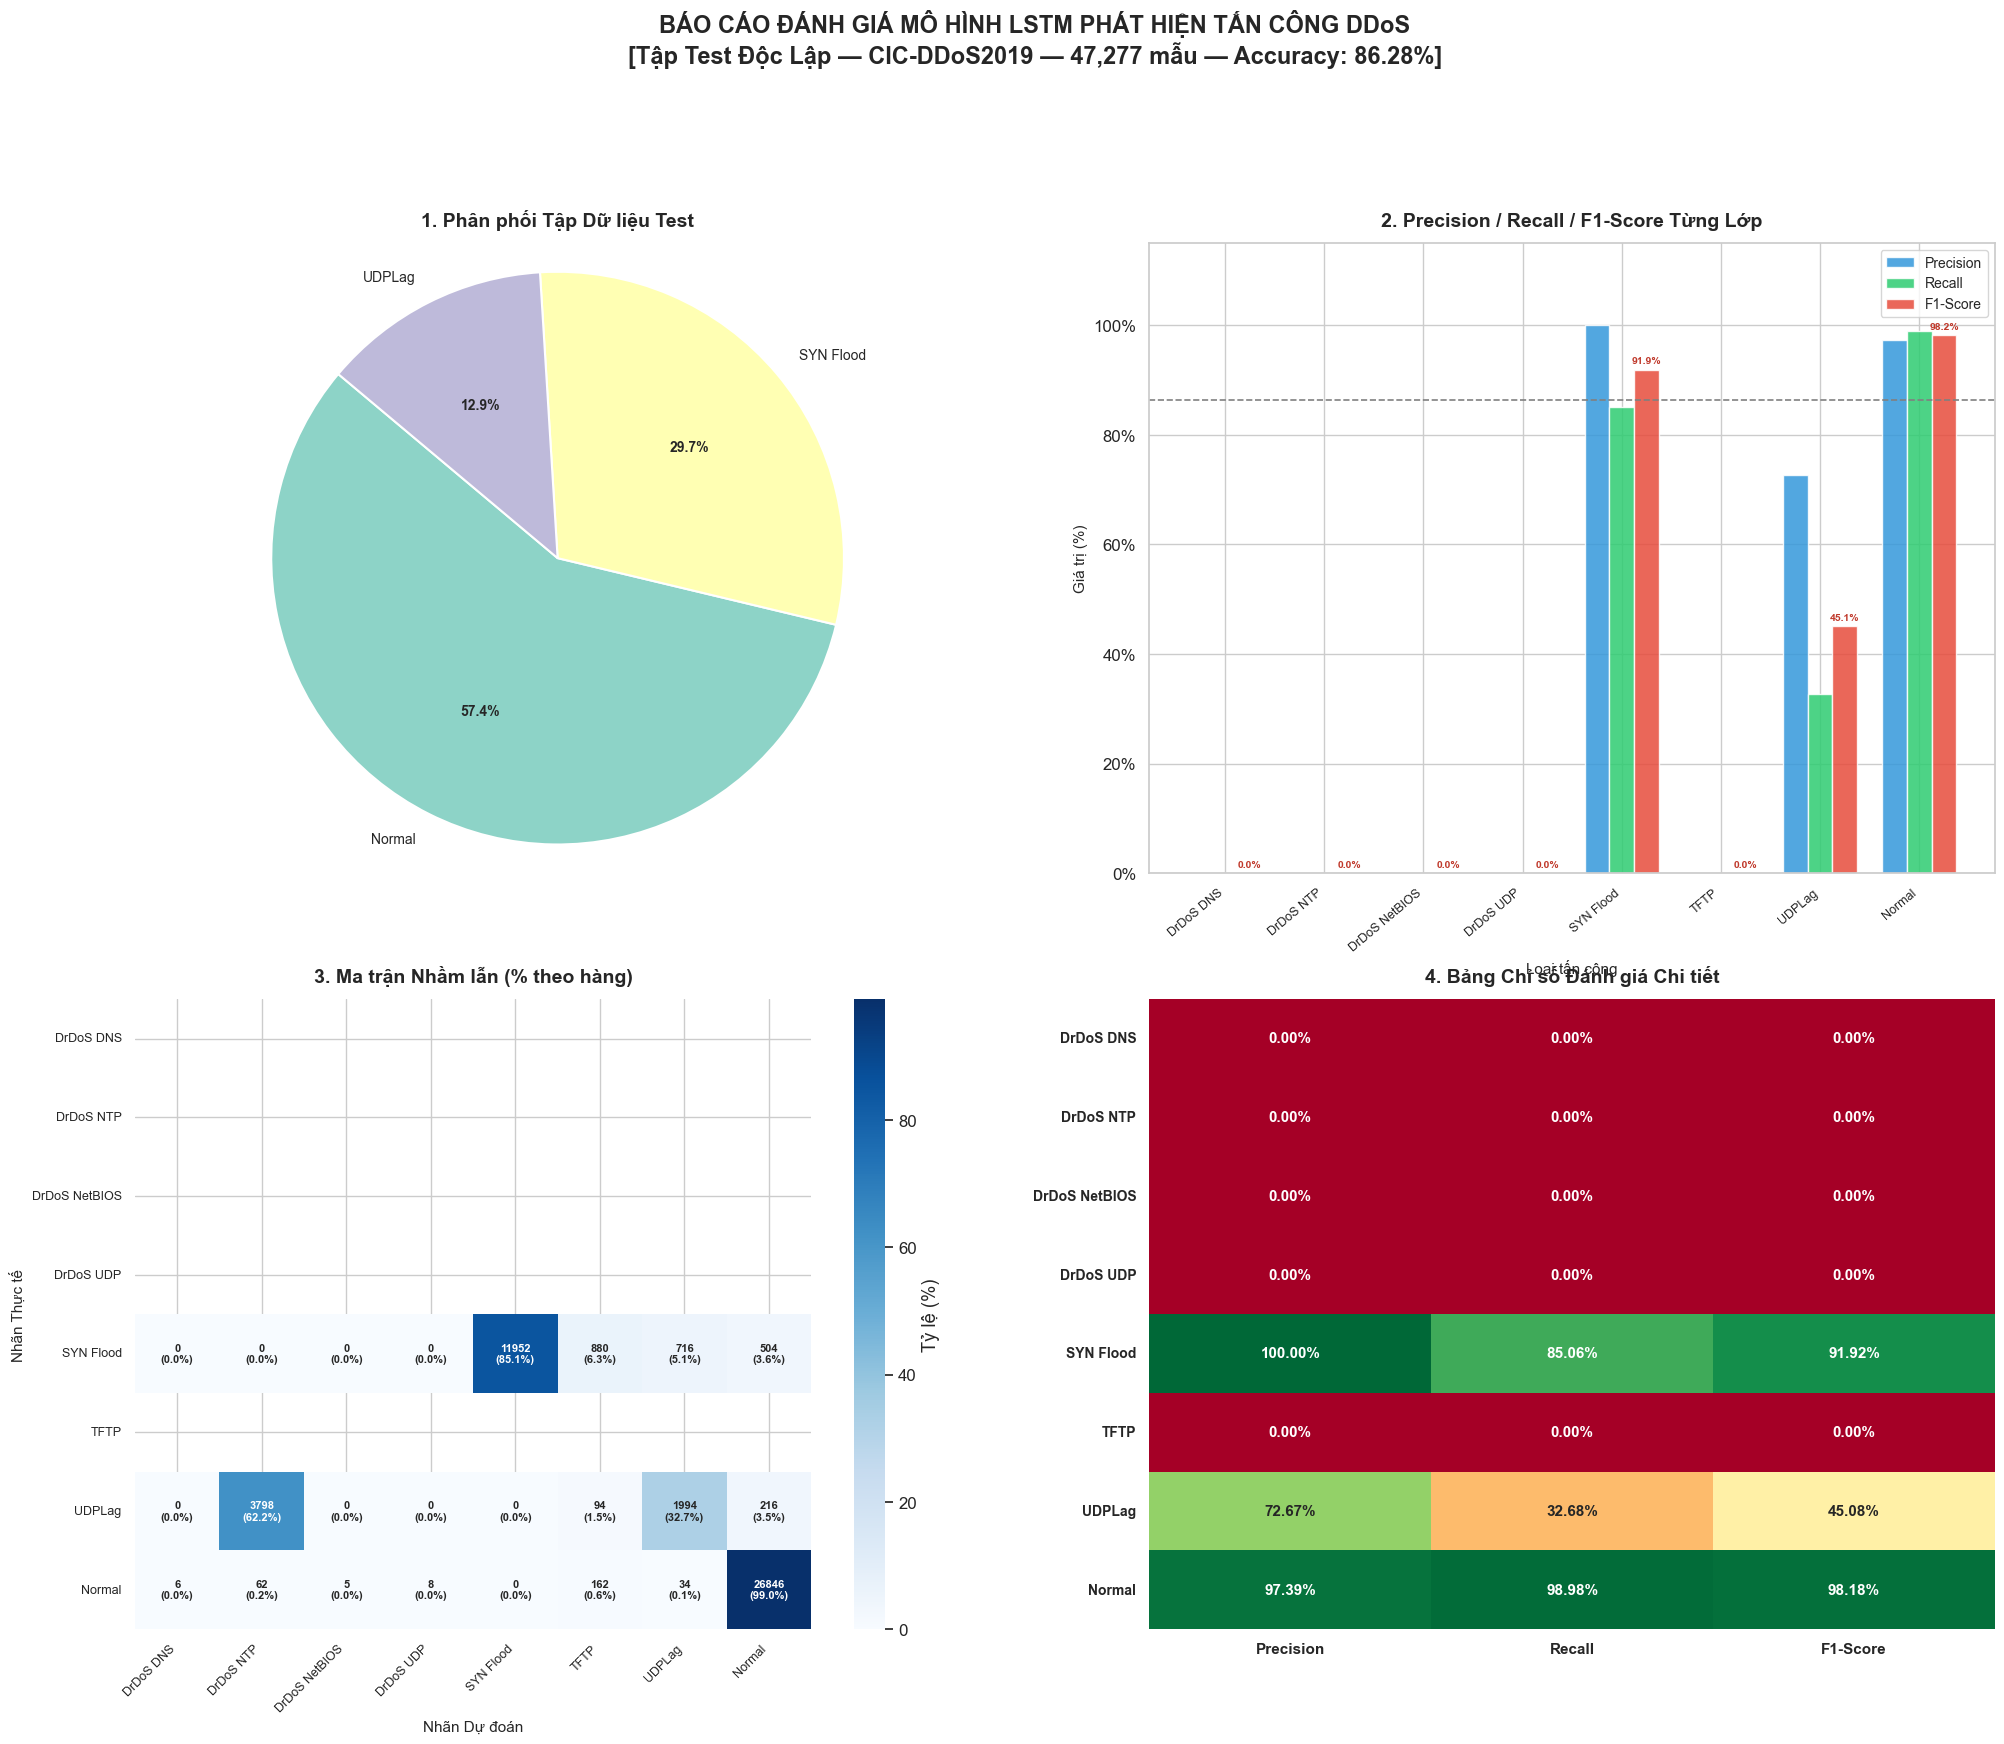

In [5]:
# ✅ FIX: Định nghĩa lại per_class_metrics ngay đầu Cell 5
per_class_metrics = pd.DataFrame(report_dict).transpose()
per_class_metrics = per_class_metrics.loc[
    present_label_names,
    ['precision', 'recall', 'f1-score']
].astype(float)

# Kiểm tra nhanh
print(f"✅ per_class_metrics shape: {per_class_metrics.shape}")
print(per_class_metrics.round(4))
sns.set_theme(style="whitegrid", font_scale=1.1)
fig = plt.figure(figsize=(24, 18))
fig.suptitle(
    'BÁO CÁO ĐÁNH GIÁ MÔ HÌNH LSTM PHÁT HIỆN TẤN CÔNG DDoS\n'
    f'[Tập Test Độc Lập — CIC-DDoS2019 — {len(df_test):,} mẫu — Accuracy: {overall_acc*100:.2f}%]',
    fontsize=17, fontweight='bold', y=1.01
)

# -------------------------------------------------------
# BIỂU ĐỒ 1: PHÂN PHỐI DỮ LIỆU TEST (PIE CHART)
# -------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
label_counts = df_test['Label'].value_counts()
display_labels = [CLASS_DISPLAY[CLASS_NAMES.index(l)] for l in label_counts.index]
colors = sns.color_palette('Set3', NUM_CLASSES)
wedges, texts, autotexts = ax1.pie(
    label_counts.values,
    labels=display_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('1. Phân phối Tập Dữ liệu Test', fontsize=14, fontweight='bold', pad=12)
ax1.axis('equal')

# -------------------------------------------------------
# BIỂU ĐỒ 2: F1-SCORE TỪNG LỚP (BAR CHART)
# -------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)

# ✅ FIX: dùng present_label_names thay vì CLASS_DISPLAY
x = np.arange(len(present_label_names))
width = 0.25

bars1 = ax2.bar(x - width, per_class_metrics['precision'] * 100, width, label='Precision', color='#3498DB', alpha=0.85)
bars2 = ax2.bar(x,         per_class_metrics['recall']    * 100, width, label='Recall',    color='#2ECC71', alpha=0.85)
bars3 = ax2.bar(x + width, per_class_metrics['f1-score']  * 100, width, label='F1-Score',  color='#E74C3C', alpha=0.85)

ax2.set_xlabel('Loại tấn công', fontsize=11)
ax2.set_ylabel('Giá trị (%)', fontsize=11)
ax2.set_title('2. Precision / Recall / F1-Score Từng Lớp', fontsize=14, fontweight='bold', pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(present_label_names, rotation=40, ha='right', fontsize=9)  # ✅
ax2.set_ylim([0, 115])
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=10)
ax2.axhline(y=overall_acc * 100, color='gray', linestyle='--', linewidth=1.2)

for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#C0392B')

# -------------------------------------------------------
# BIỂU ĐỒ 3: CONFUSION MATRIX
# -------------------------------------------------------
ax3 = fig.add_subplot(2, 2, 3)
cm = confusion_matrix(y_test_true, y_pred, labels=present_label_ids)  # ✅
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

annot_labels = np.array([
    [f"{cm[i,j]}\n({cm_normalized[i,j]:.1f}%)" for j in range(len(present_label_ids))]
    for i in range(len(present_label_ids))
])

sns.heatmap(
    cm_normalized, annot=annot_labels, fmt='', cmap='Blues',
    xticklabels=present_label_names,  # ✅
    yticklabels=present_label_names,  # ✅
    cbar_kws={'label': 'Tỷ lệ (%)'},
    annot_kws={'size': 8, 'weight': 'bold'}, ax=ax3
)
ax3.set_title('3. Ma trận Nhầm lẫn (% theo hàng)', fontsize=14, fontweight='bold', pad=12)
ax3.set_xticklabels(present_label_names, rotation=45, ha='right', fontsize=9)
ax3.set_yticklabels(present_label_names, rotation=0, fontsize=9)
ax3.set_ylabel('Nhãn Thực tế', fontsize=11)
ax3.set_xlabel('Nhãn Dự đoán', fontsize=11)

# -------------------------------------------------------
# BIỂU ĐỒ 4: HEATMAP CHỈ SỐ
# -------------------------------------------------------
ax4 = fig.add_subplot(2, 2, 4)
metrics_heatmap = per_class_metrics * 100  # đã là 8 lớp, dùng trực tiếp
annot_pct = np.array([[f"{v:.2f}%" for v in row] for row in metrics_heatmap.values])

sns.heatmap(
    metrics_heatmap, annot=annot_pct, fmt='', cmap='RdYlGn',
    vmin=0, vmax=100, cbar=False,
    annot_kws={'size': 11, 'weight': 'bold'}, ax=ax4
)
ax4.set_title('4. Bảng Chỉ số Đánh giá Chi tiết', fontsize=14, fontweight='bold', pad=12)
ax4.set_yticklabels(present_label_names, rotation=0, fontsize=10, fontweight='bold')  # ✅
ax4.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11, fontweight='bold')

## 📉 PHẦN 6: ROC CURVE ĐA LỚP (AUC)

📈 Đang tính toán ROC Curve đa lớp...


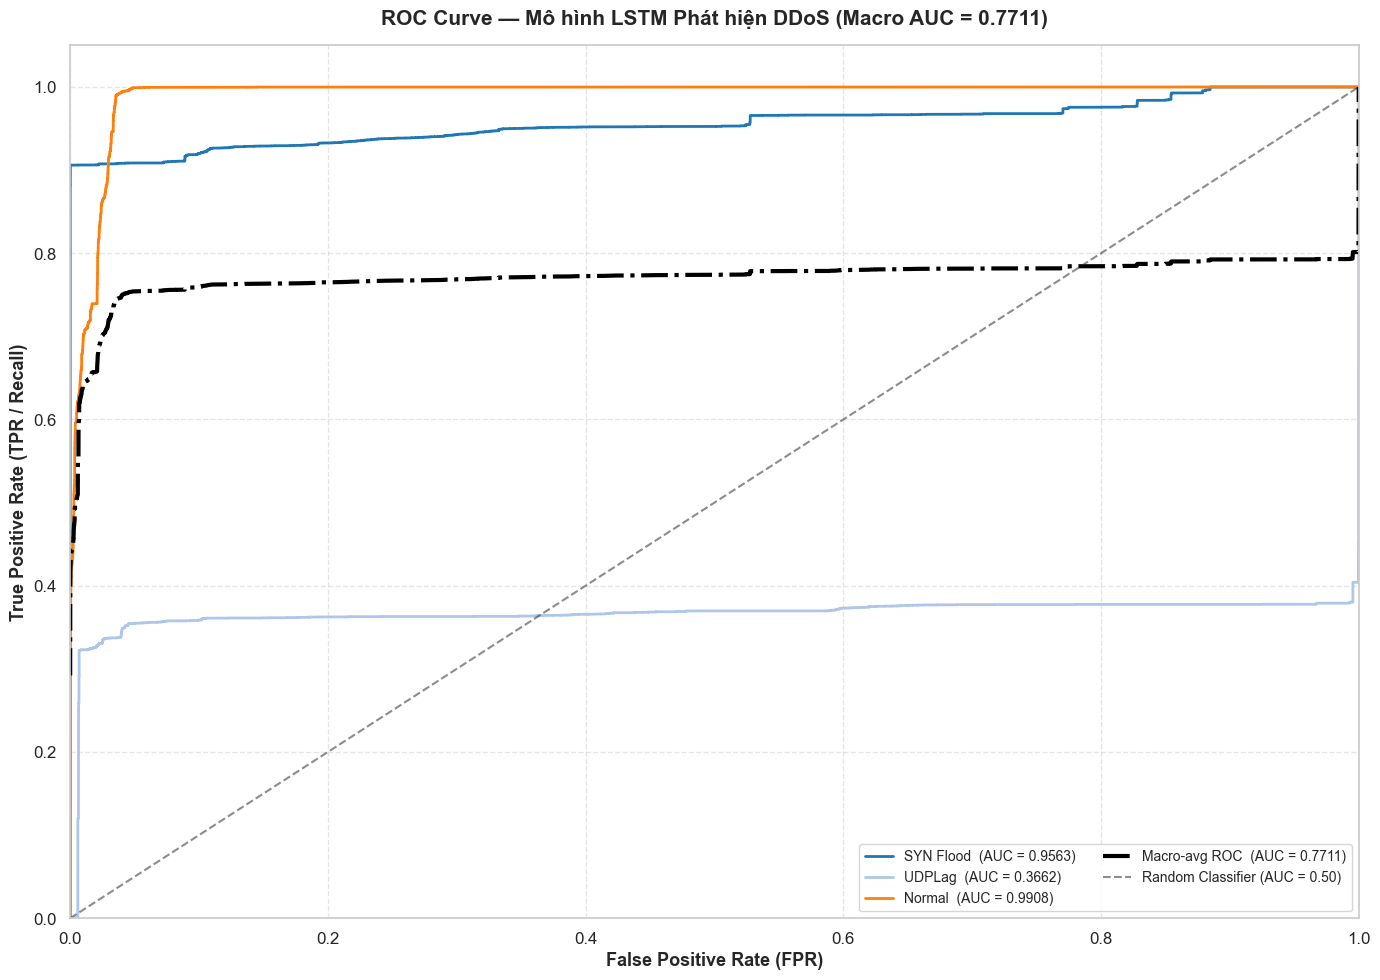


 AUC TỪNG LỚP TẤN CÔNG:
  DrDoS DNS            | ── không có mẫu trong tập test ──
  DrDoS LDAP           | ── không có mẫu trong tập test ──
  DrDoS MSSQL          | ── không có mẫu trong tập test ──
  DrDoS NTP            | ── không có mẫu trong tập test ──
  DrDoS NetBIOS        | ── không có mẫu trong tập test ──
  DrDoS SNMP           | ── không có mẫu trong tập test ──
  DrDoS SSDP           | ── không có mẫu trong tập test ──
  DrDoS UDP            | ── không có mẫu trong tập test ──
  SYN Flood            | ████████████████████████████░░ 0.9563
  TFTP                 | ── không có mẫu trong tập test ──
  UDPLag               | ██████████░░░░░░░░░░░░░░░░░░░░ 0.3662
  Normal               | █████████████████████████████░ 0.9908
-------------------------------------------------------
  Macro Average        | 0.7711  (3/12 lớp)

✅ Đã lưu: test_roc_curve.png


In [6]:
# ============================================================
# ROC CURVE CHO TỪNG LỚP
# ============================================================
print("📈 Đang tính toán ROC Curve đa lớp...")
y_test_bin = label_binarize(y_test_true, classes=range(NUM_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}

# ✅ FIX: chỉ tính ROC cho lớp có mẫu trong tập test
for i in range(NUM_CLASSES):
    if i not in present_label_ids or y_test_bin[:, i].sum() == 0:
        roc_auc[i] = float('nan')
        continue
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ✅ FIX: Macro-average chỉ dùng lớp có AUC hợp lệ
valid_ids = [i for i in range(NUM_CLASSES) if not np.isnan(roc_auc[i])]
all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_ids]))
mean_tpr = np.zeros_like(all_fpr)
for i in valid_ids:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(valid_ids)
macro_auc = auc(all_fpr, mean_tpr)

# ✅ FIX: Vẽ biểu đồ chỉ cho lớp hợp lệ
fig_roc, ax_roc = plt.subplots(figsize=(14, 10))
colors_roc = cycle(sns.color_palette('tab20', len(valid_ids)))

for i, color in zip(valid_ids, colors_roc):  # ✅ zip(valid_ids, ...)
    ax_roc.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f'{CLASS_DISPLAY[i]}  (AUC = {roc_auc[i]:.4f})'
    )

ax_roc.plot(
    all_fpr, mean_tpr,
    color='black', lw=3, linestyle='-.',
    label=f'Macro-avg ROC  (AUC = {macro_auc:.4f})'
)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.50)')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=13, fontweight='bold')
ax_roc.set_title(
    f'ROC Curve — Mô hình LSTM Phát hiện DDoS (Macro AUC = {macro_auc:.4f})',
    fontsize=15, fontweight='bold', pad=15
)
ax_roc.legend(loc='lower right', fontsize=10, ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('test_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Tóm tắt AUC từng lớp
print("\n" + "=" * 55)
print(" AUC TỪNG LỚP TẤN CÔNG:")
print("=" * 55)
for i in range(NUM_CLASSES):
    name    = CLASS_DISPLAY[i]
    auc_val = roc_auc[i]
    if np.isnan(auc_val):
        print(f"  {name:<20} | ── không có mẫu trong tập test ──")
    else:
        bar_len = int(auc_val * 30)
        bar = '█' * bar_len + '░' * (30 - bar_len)
        print(f"  {name:<20} | {bar} {auc_val:.4f}")
print("-" * 55)
print(f"  {'Macro Average':<20} | {macro_auc:.4f}  ({len(valid_ids)}/{NUM_CLASSES} lớp)")
print("=" * 55)
print("\n✅ Đã lưu: test_roc_curve.png")

## ⚖️ PHẦN 7: SO SÁNH TRAIN vs TEST

╔══════════════════════════════════════════════════════════╗
║         SO SÁNH HIỆU NĂNG TRAIN vs TEST ĐỘC LẬP         ║
╠══════════════════════════════════════════╦═══════════════╣
║  Chỉ số                                  ║     Giá trị   ║
╠══════════════════════════════════════════╬═══════════════╣
║  Train Accuracy (validation)             ║   95.5400%   ║
║  Test  Accuracy (tập độc lập)            ║   86.2830%   ║
║  Chênh lệch Accuracy                     ║   -9.2570%   ║
╠══════════════════════════════════════════╬═══════════════╣
║  Train Loss (validation)                 ║      0.128200   ║
║  Test  Loss (tập độc lập)                ║      3.002557   ║
║  Chênh lệch Loss                         ║     +2.874357   ║
╠══════════════════════════════════════════╬═══════════════╣
║  Macro AUC (ROC)                         ║      0.771116   ║
╚══════════════════════════════════════════╩═══════════════╝

📝 NHẬN XÉT:
  ⚠️  Có thể có Overfitting — Test thấp hơn Train 9.26%
     Cân nhắ

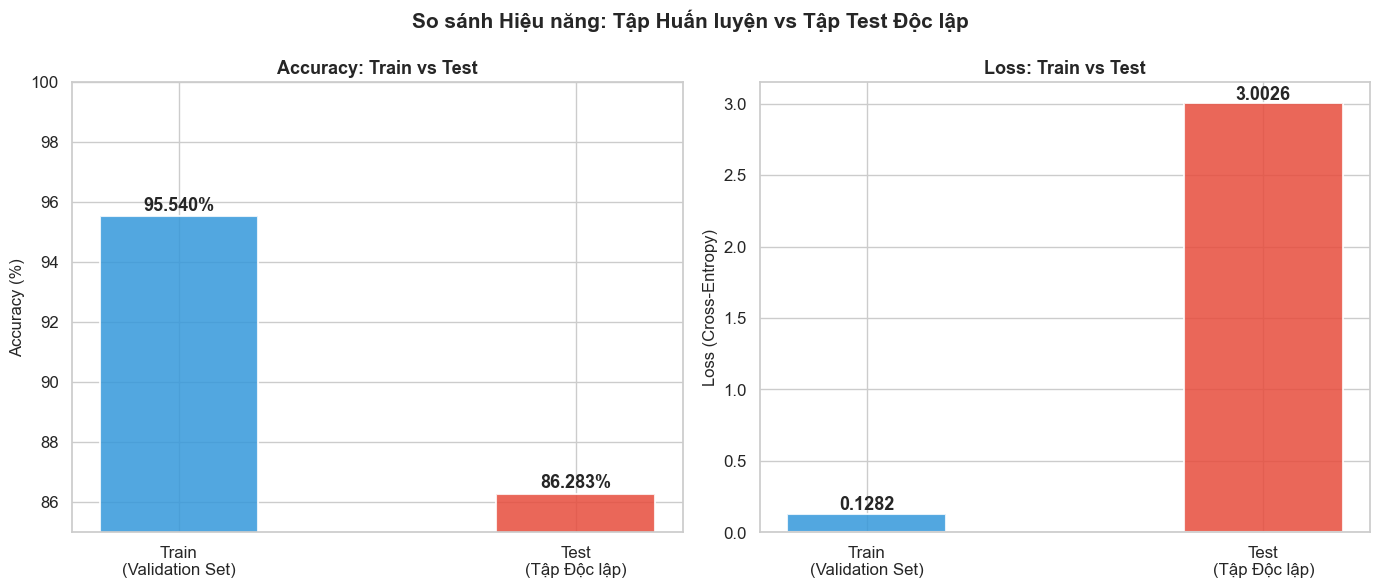


✅ Đã lưu: test_train_vs_test_comparison.png


In [7]:
# ============================================================
# SO SÁNH HIỆU NĂNG TRAIN (val_accuracy) vs TEST ĐỘC LẬP
# Điền giá trị từ kết quả training của bạn vào đây
# ============================================================
TRAIN_BEST_ACCURACY  = 0.9554  # val_accuracy tốt nhất trong training
TRAIN_BEST_LOSS      = 0.1282  # val_loss tốt nhất trong training
TRAIN_FINAL_ACCURACY = 0.9515  # accuracy epoch cuối (train set)
TRAIN_FINAL_LOSS     = 0.1447  # loss epoch cuối (train set)

TEST_ACCURACY = overall_acc
TEST_LOSS     = test_loss

diff_acc  = (TEST_ACCURACY - TRAIN_BEST_ACCURACY) * 100
diff_loss = TEST_LOSS - TRAIN_BEST_LOSS

print("╔══════════════════════════════════════════════════════════╗")
print("║         SO SÁNH HIỆU NĂNG TRAIN vs TEST ĐỘC LẬP         ║")
print("╠══════════════════════════════════════════╦═══════════════╣")
print(f"║  Chỉ số                                  ║     Giá trị   ║")
print("╠══════════════════════════════════════════╬═══════════════╣")
print(f"║  Train Accuracy (validation)             ║  {TRAIN_BEST_ACCURACY*100:>8.4f}%   ║")
print(f"║  Test  Accuracy (tập độc lập)            ║  {TEST_ACCURACY*100:>8.4f}%   ║")
print(f"║  Chênh lệch Accuracy                     ║  {diff_acc:>+8.4f}%   ║")
print("╠══════════════════════════════════════════╬═══════════════╣")
print(f"║  Train Loss (validation)                 ║  {TRAIN_BEST_LOSS:>12.6f}   ║")
print(f"║  Test  Loss (tập độc lập)                ║  {TEST_LOSS:>12.6f}   ║")
print(f"║  Chênh lệch Loss                         ║  {diff_loss:>+12.6f}   ║")
print("╠══════════════════════════════════════════╬═══════════════╣")
print(f"║  Macro AUC (ROC)                         ║  {macro_auc:>12.6f}   ║")
print("╚══════════════════════════════════════════╩═══════════════╝")

# Nhận xét tự động
print("\n📝 NHẬN XÉT:")
if abs(diff_acc) < 2.0:
    print(f"  ✅ Mô hình TỔNG QUÁT HÓA TỐT — Chênh lệch Accuracy chỉ {abs(diff_acc):.2f}%")
    print(f"     Không có dấu hiệu Overfitting đáng kể.")
elif diff_acc < -2.0:
    print(f"  ⚠️  Có thể có Overfitting — Test thấp hơn Train {abs(diff_acc):.2f}%")
    print(f"     Cân nhắc tăng Dropout hoặc giảm epochs.")
else:
    print(f"  ℹ️  Test ({TEST_ACCURACY*100:.2f}%) cao hơn Train ({TRAIN_BEST_ACCURACY*100:.2f}%) — Mô hình ổn định.")

if macro_auc >= 0.99:
    print(f"  ✅ Macro AUC = {macro_auc:.4f} — Phân biệt các lớp XUẤT SẮC")
elif macro_auc >= 0.95:
    print(f"  ✅ Macro AUC = {macro_auc:.4f} — Phân biệt các lớp RẤT TỐT")
else:
    print(f"  ⚠️  Macro AUC = {macro_auc:.4f} — Cần cải thiện khả năng phân biệt lớp")

# ============================================================
# VẼ BIỂU ĐỒ CỘT SO SÁNH
# ============================================================
fig_cmp, axes = plt.subplots(1, 2, figsize=(14, 6))
fig_cmp.suptitle('So sánh Hiệu năng: Tập Huấn luyện vs Tập Test Độc lập',
                 fontsize=15, fontweight='bold')

# Accuracy comparison
categories = ['Train\n(Validation Set)', 'Test\n(Tập Độc lập)']
acc_values  = [TRAIN_BEST_ACCURACY * 100, TEST_ACCURACY * 100]
loss_values = [TRAIN_BEST_LOSS, TEST_LOSS]

bar_colors = ['#3498DB', '#E74C3C']
bars_acc = axes[0].bar(categories, acc_values, color=bar_colors, alpha=0.85, width=0.4, edgecolor='white', linewidth=1.5)
axes[0].set_ylim([85, 100])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy: Train vs Test', fontsize=13, fontweight='bold')
for bar in bars_acc:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2., h + 0.05,
                 f'{h:.3f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

bars_loss = axes[1].bar(categories, loss_values, color=bar_colors, alpha=0.85, width=0.4, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Loss (Cross-Entropy)', fontsize=12)
axes[1].set_title('Loss: Train vs Test', fontsize=13, fontweight='bold')
for bar in bars_loss:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2., h + 0.001,
                 f'{h:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('test_train_vs_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Đã lưu: test_train_vs_test_comparison.png")

## ✅ PHẦN 8: TỔNG KẾT CUỐI

In [8]:
# ============================================================
# BẢNG TỔNG KẾT TOÀN BỘ QUÁ TRÌNH
# ============================================================
print("╔" + "═"*62 + "╗")
print("║" + " TỔNG KẾT KẾT QUẢ KIỂM THỬ MÔ HÌNH LSTM DDOS ".center(62) + "║")
print("╠" + "═"*62 + "╣")
print(f"║  Mô hình       : ddos_multiclass_final.keras".ljust(63) + "║")
print(f"║  Số lớp        : {NUM_CLASSES} (11 loại tấn công + Normal)".ljust(63) + "║")
print(f"║  Tập test      : {len(df_test):,} mẫu từ {len(df_test_list)} file CSV độc lập".ljust(63) + "║")
print("╠" + "═"*62 + "╣")
print(f"║  ✅ Test Accuracy  : {TEST_ACCURACY*100:.4f}%".ljust(63) + "║")
print(f"║  ✅ Test Loss      : {TEST_LOSS:.6f}".ljust(63) + "║")
print(f"║  ✅ Macro AUC      : {macro_auc:.6f}".ljust(63) + "║")
print(f"║  ✅ Macro F1-Score : {report_dict['macro avg']['f1-score']*100:.4f}%".ljust(63) + "║")
print(f"║  ✅ Avg Confidence : {y_confidence.mean()*100:.2f}%".ljust(63) + "║")
print("╠" + "═"*62 + "╣")
print(f"║  📄 Chi tiết       : test_results_report.csv".ljust(63) + "║")
print(f"║  🖼️  Biểu đồ chính  : test_evaluation_report.png".ljust(63) + "║")
print(f"║  🖼️  ROC Curve      : test_roc_curve.png".ljust(63) + "║")
print(f"║  🖼️  Train vs Test  : test_train_vs_test_comparison.png".ljust(63) + "║")
print("╚" + "═"*62 + "╝")

╔══════════════════════════════════════════════════════════════╗
║         TỔNG KẾT KẾT QUẢ KIỂM THỬ MÔ HÌNH LSTM DDOS          ║
╠══════════════════════════════════════════════════════════════╣
║  Mô hình       : ddos_multiclass_final.keras                 ║
║  Số lớp        : 12 (11 loại tấn công + Normal)              ║
║  Tập test      : 47,277 mẫu từ 7 file CSV độc lập            ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Test Accuracy  : 86.2830%                                 ║
║  ✅ Test Loss      : 3.002557                                 ║
║  ✅ Macro AUC      : 0.771116                                 ║
║  ✅ Macro F1-Score : 29.3980%                                 ║
║  ✅ Avg Confidence : 94.83%                                   ║
╠══════════════════════════════════════════════════════════════╣
║  📄 Chi tiết       : test_results_report.csv                  ║
║  🖼️  Biểu đồ chính  : test_evaluation_report.png             ║
║  🖼️  ROC Curve      : t